# 🎵 ATLAS — Data Extraction & Preparation

**Automatic Transcription and Lyric Alignment System**  
*Evaluating Lyric Transcription and Alignment Robustness Across Expressive Singing Styles*

**Group Members:** Antonello Giorgio · Hemanth Ramia Jegdish · Polyxeni Pouliou

---

This notebook:
1. Mounts Google Drive and extracts the GTSinger English subset
2. Explores and validates the directory structure
3. Analyses the dataset (singers, techniques, audio stats, TextGrid annotations)

**GTSinger English singers:** EN-Tenor-1, EN-Alto-1, EN-Alto-2  
**Singing techniques:** Mixed Voice, Falsetto, Breathy, Pharyngeal, Vibrato, Glissando  
**Audio format:** WAV, 48 kHz, 24-bit

## 1. Setup & Dependencies

In [ ]:
# Install required packages
!pip install -q tgt librosa pandas matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 kB 1.7 MB/s eta 0:00:00


In [ ]:
import os
import shutil
import zipfile
import json
import random
from pathlib import Path
from collections import defaultdict
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

try:
    import tgt  # TextGrid tools
except ImportError:
    print("tgt not found — TextGrid parsing will be skipped")
    tgt = None

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Plot style ─────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("Imports OK")

Imports OK


## 2. Mount Google Drive & Define Paths

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# ── Project paths ──────────────────────────────────────────────────────────────
PROJECT_DIR  = Path("/content/drive/Othercomputers/Il mio laptop/Desktop/Music Information Retrieval/Project/atlas")
ZIP_PATH     = PROJECT_DIR / "English.zip"

# Local (faster I/O than Drive once extracted)
LOCAL_DIR    = Path("/content/atlas")
EXTRACT_DIR  = LOCAL_DIR / "English_raw"       # raw unzipped data
PREPARED_DIR = LOCAL_DIR / "English_prepared"  # organised for ATLAS pipeline
META_DIR     = LOCAL_DIR / "metadata"

for d in [EXTRACT_DIR, PREPARED_DIR, META_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"ZIP source  : {ZIP_PATH}")
print(f"Extract to  : {EXTRACT_DIR}")
print(f"Prepared    : {PREPARED_DIR}")
print(f"Metadata    : {META_DIR}")
print(f"ZIP exists  : {ZIP_PATH.exists()}")

ZIP source  : /content/drive/Othercomputers/Il mio laptop/Desktop/Music Information Retrieval/Project/atlas/English.zip
Extract to  : /content/atlas/English_raw
Prepared    : /content/atlas/English_prepared
Metadata    : /content/atlas/metadata
ZIP exists  : True


## 3. Unzip English Subset

In [ ]:
if not any(EXTRACT_DIR.iterdir()) if EXTRACT_DIR.exists() else True:
    print(f"📦 Unzipping {ZIP_PATH.name} ...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        members = zf.namelist()
        print(f"   Total entries in ZIP: {len(members):,}")
        for member in tqdm(members, desc="Extracting"):
            zf.extract(member, EXTRACT_DIR)
    print("✅ Extraction complete")
else:
    print("⏭️  Already extracted — skipping unzip")

# Count extracted files
all_files = list(EXTRACT_DIR.rglob("*"))
print(f"\nTotal items (files + dirs) extracted: {len(all_files):,}")

📦 Unzipping English.zip ...
   Total entries in ZIP: 25,984


Extracting:   0%|          | 0/25984 [00:00<?, ?it/s]

✅ Extraction complete

Total items (files + dirs) extracted: 25,999


## 4. Explore Directory Structure

In [ ]:
def print_tree(root: Path, max_depth: int = 4, max_items: int = 6):
    """Print a compact directory tree."""
    def _walk(path: Path, prefix: str, depth: int):
        if depth > max_depth:
            return
        entries = sorted(path.iterdir())
        shown = entries[:max_items]
        hidden = len(entries) - max_items
        for i, entry in enumerate(shown):
            connector = "└── " if i == len(shown) - 1 and hidden <= 0 else "├── "
            print(prefix + connector + entry.name + ("/" if entry.is_dir() else ""))
            if entry.is_dir():
                extension = "    " if connector == "└── " else "│   "
                _walk(entry, prefix + extension, depth + 1)
        if hidden > 0:
            print(prefix + f"└── ... ({hidden} more)")

print(f"{EXTRACT_DIR}/")
_walk = lambda path, prefix, depth: None  # placeholder to avoid NameError below
print_tree(EXTRACT_DIR)

/content/atlas/English_raw/


In [ ]:
# ── Detect the English root (some zips nest an extra folder) ──────────────────
def find_english_root(base: Path) -> Path:
    """Walk down until we find a directory that looks like the English singer root."""
    for p in base.rglob("*"):
        if p.is_dir() and any(s in p.name for s in ["EN-Tenor", "EN-Alto", "English"]):
            # Return the parent that contains singers
            return p.parent if "EN-" in p.name else p
    return base  # fallback

ENGLISH_ROOT = find_english_root(EXTRACT_DIR)
print(f"English data root: {ENGLISH_ROOT}")

English data root: /content/atlas/English_raw/English


## 5. Inventory: Collect All Files

In [ ]:
# GTSinger folder naming conventions (from paper & script)
# Structure: English / <Singer_ID> / <Technique_Folder> / <Group_Folder> / *.wav + *.TextGrid + *.musicxml

TECHNIQUE_KEYWORDS = {
    "Mixed_Voice": "mixed_voice",
    "MixedVoice":  "mixed_voice",
    "Falsetto":    "falsetto",
    "Breathy":     "breathy",
    "Pharyngeal":  "pharyngeal",
    "Vibrato":     "vibrato",
    "Glissando":   "glissando",
}

GROUP_KEYWORDS = {
    "Technique_Group":    "technique",
    "TechniqueGroup":     "technique",
    "Control_Group":      "control",
    "ControlGroup":       "control",
    "Paired_Speech_Group": "speech",
    "PairedSpeech":       "speech",
}

def classify_path(parts: list[str], keyword_map: dict) -> str:
    for part in parts:
        for kw, label in keyword_map.items():
            if kw.lower() in part.lower():
                return label
    return "unknown"

records = []

for wav in tqdm(list(ENGLISH_ROOT.rglob("*.wav")), desc="Scanning WAV files"):
    if wav.name.startswith("._"):
        continue  # macOS metadata files

    parts = wav.parts

    # Singer ID
    singer_id = "unknown"
    for part in parts:
        if "EN-" in part:
            singer_id = part
            break

    technique  = classify_path(list(parts), TECHNIQUE_KEYWORDS)
    group      = classify_path(list(parts), GROUP_KEYWORDS)
    song_id    = wav.stem

    # Companion TextGrid
    tg_path = wav.with_suffix(".TextGrid")
    has_textgrid = tg_path.exists()

    # Companion MusicXML
    xml_path = wav.with_suffix(".musicxml")
    has_musicxml = xml_path.exists()

    records.append({
        "singer_id":    singer_id,
        "technique":    technique,
        "group":        group,
        "song_id":      song_id,
        "wav_path":     str(wav),
        "tg_path":      str(tg_path) if has_textgrid else None,
        "xml_path":     str(xml_path) if has_musicxml else None,
        "has_textgrid": has_textgrid,
        "has_musicxml": has_musicxml,
    })

df = pd.DataFrame(records)
print(f"\n📊 Total WAV files found: {len(df):,}")
print(df[["singer_id", "technique", "group"]].value_counts().to_string())

Scanning WAV files:   0%|          | 0/6892 [00:00<?, ?it/s]


📊 Total WAV files found: 6,892
singer_id   technique    group  
EN-Tenor-1  mixed_voice  unknown    542
EN-Alto-2   mixed_voice  unknown    490
EN-Alto-1   mixed_voice  unknown    365
EN-Tenor-1  mixed_voice  speech     271
                         control    271
EN-Alto-2   mixed_voice  control    245
                         speech     245
EN-Alto-1   mixed_voice  control    184
                         speech     184
EN-Tenor-1  breathy      unknown    136
                         control    136
                         speech     136
            glissando    speech     128
                         control    128
                         unknown    128
            vibrato      control    127
                         speech     127
                         unknown    127
EN-Alto-2   glissando    control    126
            vibrato      control    126
            glissando    speech     126
            vibrato      unknown    126
                         speech     126
            gli

In [ ]:
print("=== Dataset Overview ===")
print(f"Total utterances : {len(df):,}")
print(f"Singers          : {df['singer_id'].nunique()} — {sorted(df['singer_id'].unique())}")
print(f"Techniques       : {sorted(df['technique'].unique())}")
print(f"Groups           : {sorted(df['group'].unique())}")
print(f"With TextGrid    : {df['has_textgrid'].sum():,} ({df['has_textgrid'].mean()*100:.1f}%)")
print(f"With MusicXML    : {df['has_musicxml'].sum():,} ({df['has_musicxml'].mean()*100:.1f}%)")
print()
print(df.groupby(["singer_id", "technique", "group"]).size().rename("count").reset_index().to_string(index=False))

=== Dataset Overview ===
Total utterances : 6,892
Singers          : 3 — ['EN-Alto-1', 'EN-Alto-2', 'EN-Tenor-1']
Techniques       : ['breathy', 'glissando', 'mixed_voice', 'pharyngeal', 'vibrato']
Groups           : ['control', 'speech', 'unknown']
With TextGrid    : 5,209 (75.6%)
With MusicXML    : 4,827 (70.0%)

 singer_id   technique   group  count
 EN-Alto-1     breathy control    103
 EN-Alto-1     breathy  speech    103
 EN-Alto-1     breathy unknown    103
 EN-Alto-1   glissando control     99
 EN-Alto-1   glissando  speech     99
 EN-Alto-1   glissando unknown     99
 EN-Alto-1 mixed_voice control    184
 EN-Alto-1 mixed_voice  speech    184
 EN-Alto-1 mixed_voice unknown    365
 EN-Alto-1  pharyngeal control    102
 EN-Alto-1  pharyngeal  speech    102
 EN-Alto-1  pharyngeal unknown    102
 EN-Alto-1     vibrato control     49
 EN-Alto-1     vibrato  speech     49
 EN-Alto-1     vibrato unknown     49
 EN-Alto-2     breathy control    122
 EN-Alto-2     breathy  speech    122

## 6. Audio Analysis

In [ ]:
# Sample a subset for quick duration analysis (full pass can be slow on Drive)
SAMPLE_N = min(200, len(df))
sample_df = df.sample(SAMPLE_N, random_state=SEED).copy()

durations = []
sample_rates = []

for _, row in tqdm(sample_df.iterrows(), total=SAMPLE_N, desc="Reading audio metadata"):
    try:
        info = librosa.get_samplerate(row["wav_path"])
        y, sr = librosa.load(row["wav_path"], sr=None, mono=True)
        durations.append(len(y) / sr)
        sample_rates.append(sr)
    except Exception as e:
        durations.append(np.nan)
        sample_rates.append(np.nan)

sample_df["duration_s"] = durations
sample_df["sample_rate"] = sample_rates

print("=== Audio Stats (sampled) ===")
print(sample_df["duration_s"].describe().round(3))
print(f"\nSample rates observed: {set(sample_rates) - {np.nan}}")

Reading audio metadata:   0%|          | 0/200 [00:00<?, ?it/s]

=== Audio Stats (sampled) ===
count    200.000
mean       8.197
std        3.424
min        1.187
25%        6.127
50%        8.034
75%        9.758
max       19.864
Name: duration_s, dtype: float64

Sample rates observed: {48000}


/tmp/ipython-input-210/749155414.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample_df, x="technique", y="duration_s", order=order, ax=ax, palette="muted")
/tmp/ipython-input-210/749155414.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
/tmp/ipython-input-210/749155414.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample_df, x="singer_id", y="duration_s", ax=ax, palette="pastel")
/tmp/ipython-input-210/749155414.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.

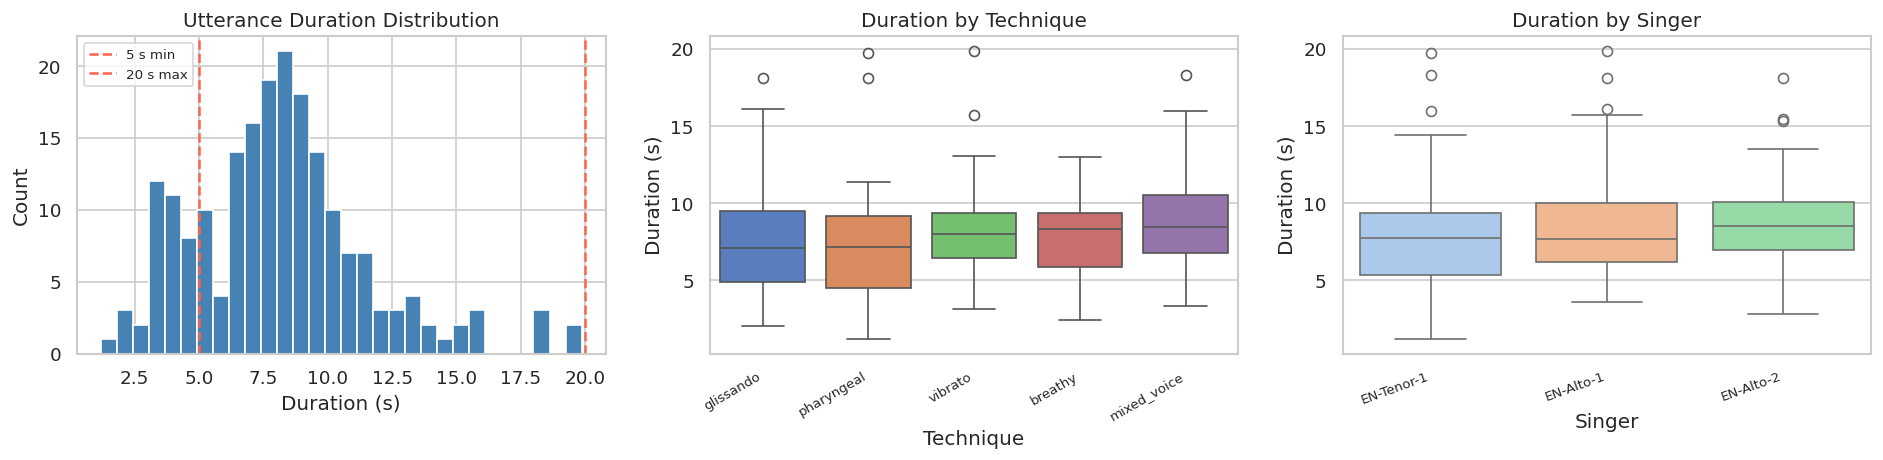

Saved → duration_analysis.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Duration histogram
ax = axes[0]
ax.hist(sample_df["duration_s"].dropna(), bins=30, color="steelblue", edgecolor="white")
ax.axvline(5,  color="tomato", linestyle="--", label="5 s min")
ax.axvline(20, color="tomato", linestyle="--", label="20 s max")
ax.set_xlabel("Duration (s)")
ax.set_ylabel("Count")
ax.set_title("Utterance Duration Distribution")
ax.legend(fontsize=8)

# Duration by technique
ax = axes[1]
order = sample_df.groupby("technique")["duration_s"].median().sort_values().index
sns.boxplot(data=sample_df, x="technique", y="duration_s", order=order, ax=ax, palette="muted")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
ax.set_xlabel("Technique")
ax.set_ylabel("Duration (s)")
ax.set_title("Duration by Technique")

# Duration by singer
ax = axes[2]
sns.boxplot(data=sample_df, x="singer_id", y="duration_s", ax=ax, palette="pastel")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right", fontsize=8)
ax.set_xlabel("Singer")
ax.set_ylabel("Duration (s)")
ax.set_title("Duration by Singer")

plt.tight_layout()
plt.savefig(META_DIR / "duration_analysis.png", bbox_inches="tight")
plt.show()
print("Saved → duration_analysis.png")

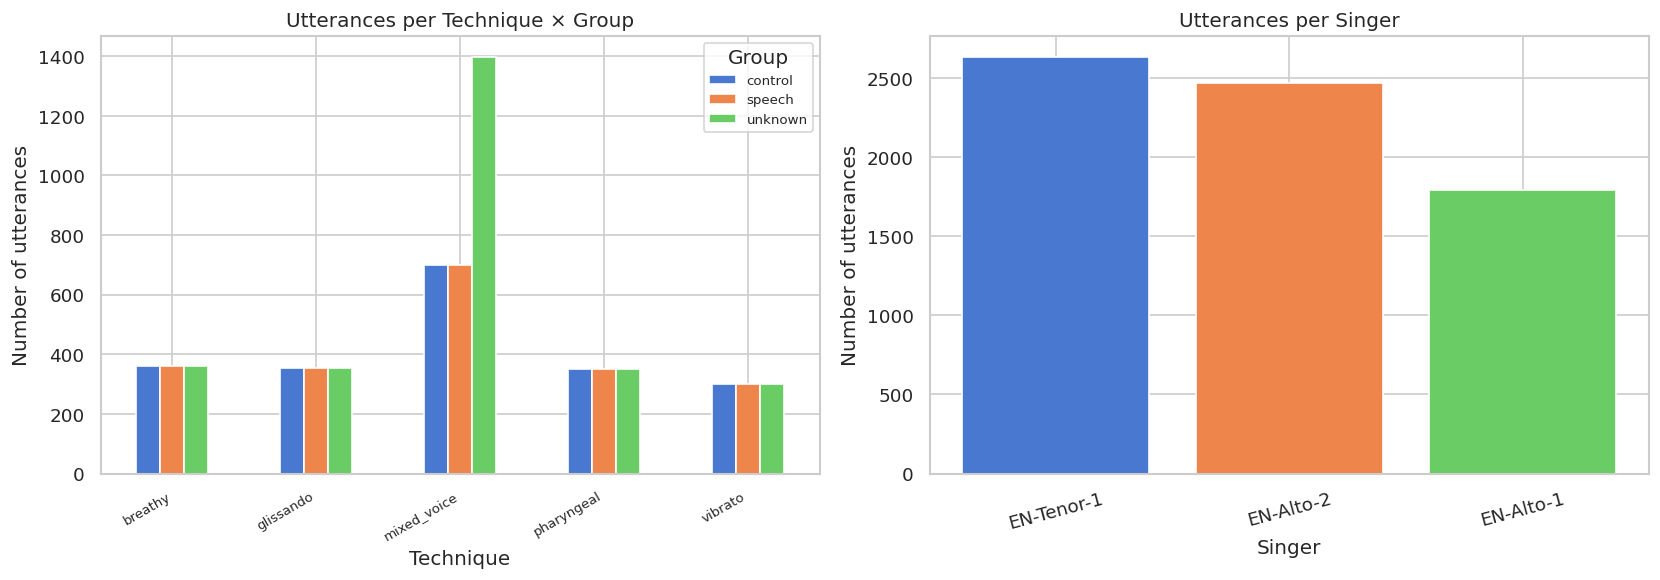

Saved → utterance_counts.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Utterances per technique × group
ax = axes[0]
pivot = df.groupby(["technique", "group"]).size().unstack(fill_value=0)
pivot.plot(kind="bar", ax=ax, edgecolor="white")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
ax.set_xlabel("Technique")
ax.set_ylabel("Number of utterances")
ax.set_title("Utterances per Technique × Group")
ax.legend(title="Group", fontsize=8)

# Utterances per singer
ax = axes[1]
singer_counts = df["singer_id"].value_counts().reset_index()
singer_counts.columns = ["singer_id", "count"]
ax.bar(singer_counts["singer_id"], singer_counts["count"], color=sns.color_palette("muted")[:len(singer_counts)])
ax.set_xlabel("Singer")
ax.set_ylabel("Number of utterances")
ax.set_title("Utterances per Singer")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(META_DIR / "utterance_counts.png", bbox_inches="tight")
plt.show()
print("Saved → utterance_counts.png")

## 7. TextGrid (Annotation) Analysis

In [ ]:
if tgt is None:
    print("⚠️  tgt not installed — skipping TextGrid analysis")
else:
    tg_files = df[df["has_textgrid"]]["tg_path"].dropna().tolist()
    SAMPLE_TG = min(50, len(tg_files))
    sample_tg = random.sample(tg_files, SAMPLE_TG)

    tier_names_seen = defaultdict(int)
    phoneme_counts = []
    word_counts    = []

    for tg_path in tqdm(sample_tg, desc="Parsing TextGrids"):
        try:
            tg = tgt.io.read_textgrid(tg_path)
            for tier in tg.tiers:
                tier_names_seen[tier.name] += 1

            # Count phoneme-tier intervals (non-empty)
            for tier in tg.tiers:
                if "phone" in tier.name.lower():
                    n = sum(1 for iv in tier.intervals if iv.text.strip() not in ["", "sp", "sil", "SIL"])
                    phoneme_counts.append(n)
                elif "word" in tier.name.lower():
                    n = sum(1 for iv in tier.intervals if iv.text.strip() not in ["", "sp", "sil", "SIL"])
                    word_counts.append(n)
        except Exception as e:
            print(f"  ⚠️  Could not parse {Path(tg_path).name}: {e}")

    print("\n=== TextGrid Tier Names ===")
    for name, count in sorted(tier_names_seen.items(), key=lambda x: -x[1]):
        print(f"  {name:30s} : {count} files")

    if phoneme_counts:
        print(f"\nPhonemes per utterance — mean: {np.mean(phoneme_counts):.1f}, median: {np.median(phoneme_counts):.1f}")
    if word_counts:
        print(f"Words per utterance    — mean: {np.mean(word_counts):.1f}, median: {np.median(word_counts):.1f}")

Parsing TextGrids:   0%|          | 0/50 [00:00<?, ?it/s]


=== TextGrid Tier Names ===
  word                           : 50 files
  phone                          : 50 files
  mix                            : 33 files
  falsetto                       : 33 files
  breathy                        : 33 files
  pharyngeal                     : 33 files
  vibrato                        : 33 files
  glissando                      : 33 files
  global                         : 33 files

Phonemes per utterance — mean: 41.1, median: 37.0
Words per utterance    — mean: 15.0, median: 14.5


In [ ]:
if tgt is not None and tg_files:
    # Print a sample TextGrid's word + phoneme tiers
    example_tg_path = random.choice(tg_files)
    print(f"Example TextGrid: {Path(example_tg_path).name}\n")
    tg = tgt.io.read_textgrid(example_tg_path)
    for tier in tg.tiers:
        visible = [iv for iv in tier.intervals if iv.text.strip() not in ["", "sp", "sil", "SIL"]]
        print(f"Tier: {tier.name}")
        for iv in visible[:10]:
            print(f"  [{iv.start_time:.3f} – {iv.end_time:.3f}]  {iv.text}")
        if len(visible) > 10:
            print(f"  ... ({len(visible)-10} more intervals)")
        print()

Example TextGrid: 0001.TextGrid

Tier: word
  [0.000 – 0.297]  cause
  [0.297 – 0.861]  she
  [0.861 – 2.146]  doesn't
  [2.146 – 2.430]  get
  [2.430 – 2.788]  your
  [2.788 – 3.518]  humor
  [3.518 – 3.968]  like
  [3.968 – 4.248]  <AP>
  [4.248 – 5.187]  i
  [5.187 – 6.204]  do
  ... (1 more intervals)

Tier: phone
  [0.000 – 0.169]  K
  [0.169 – 0.247]  AA1
  [0.247 – 0.297]  Z
  [0.297 – 0.464]  SH
  [0.464 – 0.861]  IY1
  [0.861 – 0.971]  D
  [0.971 – 1.188]  AH1
  [1.188 – 1.302]  Z
  [1.302 – 1.459]  AH0
  [1.459 – 2.087]  N
  ... (20 more intervals)

Tier: mix
  [0.000 – 0.169]  0
  [0.169 – 0.247]  0
  [0.247 – 0.297]  0
  [0.297 – 0.464]  0
  [0.464 – 0.861]  0
  [0.861 – 0.971]  0
  [0.971 – 1.188]  0
  [1.188 – 1.302]  0
  [1.302 – 1.459]  0
  [1.459 – 2.087]  0
  ... (20 more intervals)

Tier: falsetto
  [0.000 – 0.169]  1
  [0.169 – 0.247]  1
  [0.247 – 0.297]  1
  [0.297 – 0.464]  1
  [0.464 – 0.861]  1
  [0.861 – 0.971]  1
  [0.971 – 1.188]  1
  [1.188 – 1.302]  1
  [1

## 8. Data Preparation for ATLAS Pipeline

We organise the English subset into a flat structure suitable for all three pipeline components:

```
English_prepared/
  singing/
    technique/   ← technique-group recordings (dense technique use)
    control/     ← control-group recordings  (natural singing)
  speech/        ← paired speech utterances
```

Each `.wav` is copied alongside its `.TextGrid` (ground-truth alignment).

In [ ]:
def prepare_atlas_dataset(df: pd.DataFrame, out_dir: Path) -> pd.DataFrame:
    """
    Copy WAV + TextGrid files into the ATLAS-ready structure and
    return an updated dataframe with new paths.
    """
    rows = []
    skipped = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Preparing files"):
        group = row["group"]

        # Map group → subfolder
        if group == "speech":
            subfolder = out_dir / "speech"
        elif group in ["technique", "control"]:
            subfolder = out_dir / "singing" / group
        else:
            skipped += 1
            continue

        # Further split by singer + technique for organisation
        dest_dir = subfolder / row["singer_id"] / row["technique"]
        dest_dir.mkdir(parents=True, exist_ok=True)

        # Build a clean filename: singerID-technique-group-songID.wav
        clean_name = f"{row['singer_id']}__{row['technique']}__{row['group']}__{row['song_id']}"

        # Copy WAV
        wav_dest = dest_dir / (clean_name + ".wav")
        if not wav_dest.exists():
            shutil.copy2(row["wav_path"], wav_dest)

        # Copy TextGrid (if available)
        tg_dest = None
        if row["has_textgrid"] and row["tg_path"]:
            tg_dest = dest_dir / (clean_name + ".TextGrid")
            if not tg_dest.exists():
                shutil.copy2(row["tg_path"], tg_dest)

        rows.append({
            **row.to_dict(),
            "prepared_wav":  str(wav_dest),
            "prepared_tg":   str(tg_dest) if tg_dest else None,
            "atlas_group":   group,
            "clean_name":    clean_name,
        })

    print(f"\n✅ Files prepared: {len(rows):,}")
    if skipped:
        print(f"⚠️  Skipped (unknown group): {skipped}")
    return pd.DataFrame(rows)


prepared_df = prepare_atlas_dataset(df, PREPARED_DIR)

Preparing files:   0%|          | 0/6892 [00:00<?, ?it/s]


✅ Files prepared: 4,130
⚠️  Skipped (unknown group): 2762


## 9. Export Lyrics Transcript List for FireRedASR

FireRedASR (transcription baseline) needs a **list of WAV paths** as input. We export one `.txt` manifest per split (singing / speech).

In [ ]:
def extract_lyrics_from_textgrid(tg_path: str) -> str:
    """Extract word-level ground-truth lyrics from a TextGrid file."""
    if tgt is None or not tg_path:
        return ""
    try:
        tg = tgt.io.read_textgrid(tg_path)
        for tier in tg.tiers:
            if "word" in tier.name.lower():
                words = [iv.text.strip() for iv in tier.intervals
                         if iv.text.strip() and iv.text.strip().lower() not in ["sp", "sil", "<sil>", "spn"]]
                return " ".join(words)
    except Exception:
        pass
    return ""


# Extract lyrics for all utterances that have TextGrids
print("Extracting ground-truth lyrics from TextGrids...")
prepared_df["gt_lyrics"] = prepared_df["prepared_tg"].apply(
    lambda p: extract_lyrics_from_textgrid(p) if pd.notna(p) else ""
)

with_lyrics = prepared_df[prepared_df["gt_lyrics"].str.len() > 0]
print(f"Utterances with extracted lyrics: {len(with_lyrics):,} / {len(prepared_df):,}")

Extracting ground-truth lyrics from TextGrids...
Utterances with extracted lyrics: 3,126 / 4,130


In [ ]:
# ── Write manifests ────────────────────────────────────────────────────────────
# 1. WAV-only manifest for FireRedASR (transcription)
singing_wavs = prepared_df[prepared_df["atlas_group"].isin(["technique", "control"])]
speech_wavs  = prepared_df[prepared_df["atlas_group"] == "speech"]

manifests = {
    "singing_wav_list.txt": singing_wavs["prepared_wav"],
    "speech_wav_list.txt":  speech_wavs["prepared_wav"],
    "all_wav_list.txt":     prepared_df["prepared_wav"],
}

for fname, paths in manifests.items():
    out = META_DIR / fname
    out.write_text("\n".join(paths.dropna().tolist()))
    print(f"  Wrote {fname}: {len(paths):,} entries")

# 2. MFA-ready transcript file: <utt_id> <lyrics>
#    MFA expects a corpus folder where each wav has a matching .lab or .txt file
mfa_corpus_dir = META_DIR / "mfa_corpus"
mfa_corpus_dir.mkdir(exist_ok=True)

mfa_count = 0
for _, row in prepared_df.iterrows():
    if row["gt_lyrics"] and pd.notna(row["prepared_wav"]):
        lab_path = mfa_corpus_dir / (row["clean_name"] + ".lab")
        lab_path.write_text(row["gt_lyrics"])
        # Symlink (or copy) WAV into MFA corpus
        wav_link = mfa_corpus_dir / (row["clean_name"] + ".wav")
        if not wav_link.exists():
            try:
                wav_link.symlink_to(row["prepared_wav"])
            except Exception:
                shutil.copy2(row["prepared_wav"], wav_link)
        mfa_count += 1

print(f"\n  MFA corpus entries written: {mfa_count:,} → {mfa_corpus_dir}")

  Wrote singing_wav_list.txt: 2,065 entries
  Wrote speech_wav_list.txt: 2,065 entries
  Wrote all_wav_list.txt: 4,130 entries

  MFA corpus entries written: 3,126 → /content/atlas/metadata/mfa_corpus


## 10. Export Metadata CSV

In [ ]:
# Save complete metadata
meta_path = META_DIR / "atlas_english_metadata.csv"
prepared_df.to_csv(meta_path, index=False)
print(f"✅ Metadata saved → {meta_path}")
print(f"   Shape: {prepared_df.shape}")
print()
prepared_df.head(5)

✅ Metadata saved → /content/atlas/metadata/atlas_english_metadata.csv
   Shape: (4130, 14)



,singer_id,technique,group,song_id,wav_path,tg_path,xml_path,has_textgrid,has_musicxml,prepared_wav,prepared_tg,atlas_group,clean_name,gt_lyrics
0,EN-Tenor-1,vibrato,control,0006,/content/atlas/English_raw/English/EN-Tenor-1/...,/content/atlas/English_raw/English/EN-Tenor-1/...,/content/atlas/English_raw/English/EN-Tenor-1/...,True,True,/content/atlas/English_prepared/singing/contro...,/content/atlas/English_prepared/singing/contro...,control,EN-Tenor-1__vibrato__control__0006,hold me like i'm more than just a friend <AP>
1,EN-Tenor-1,vibrato,control,0001,/content/atlas/English_raw/English/EN-Tenor-1/...,/content/atlas/English_raw/English/EN-Tenor-1/...,/content/atlas/English_raw/English/EN-Tenor-1/...,True,True,/content/atlas/English_prepared/singing/contro...,/content/atlas/English_prepared/singing/contro...,control,EN-Tenor-1__vibrato__control__0001,they've all been said before you know <AP> so ...
2,EN-Tenor-1,vibrato,control,0000,/content/atlas/English_raw/English/EN-Tenor-1/...,/content/atlas/English_raw/English/EN-Tenor-1/...,/content/atlas/English_raw/English/EN-Tenor-1/...,True,True,/content/atlas/English_prepared/singing/contro...,/content/atlas/English_prepared/singing/contro...,control,EN-Tenor-1__vibrato__control__0000,<SP> i will leave <SP> my heart at the door <A...
3,EN-Tenor-1,vibrato,control,0007,/content/atlas/English_raw/English/EN-Tenor-1/...,/content/atlas/English_raw/English/EN-Tenor-1/...,/content/atlas/English_raw/English/EN-Tenor-1/...,True,True,/content/atlas/English_prepared/singing/contro...,/content/atlas/English_prepared/singing/contro...,control,EN-Tenor-1__vibrato__control__0007,give me a memory i can use <AP>
4,EN-Tenor-1,vibrato,control,0004,/content/atlas/English_raw/English/EN-Tenor-1/...,/content/atlas/English_raw/English/EN-Tenor-1/...,/content/atlas/English_raw/English/EN-Tenor-1/...,True,True,/content/atlas/English_prepared/singing/contro...,/content/atlas/English_prepared/singing/contro...,control,EN-Tenor-1__vibrato__control__0004,<SP> all i ask <AP> is if <AP>


In [ ]:
# ── Summary statistics by technique & group ────────────────────────────────────
summary = (
    prepared_df
    .groupby(["singer_id", "technique", "atlas_group"])
    .agg(
        n_utterances=("prepared_wav", "count"),
        with_textgrid=("has_textgrid", "sum"),
        with_lyrics=("gt_lyrics", lambda x: (x.str.len() > 0).sum()),
    )
    .reset_index()
)

summary_path = META_DIR / "atlas_english_summary.csv"
summary.to_csv(summary_path, index=False)
print(f"Summary saved → {summary_path}")
print()
print(summary.to_string(index=False))

Summary saved → /content/atlas/metadata/atlas_english_summary.csv

 singer_id   technique atlas_group  n_utterances  with_textgrid  with_lyrics
 EN-Alto-1     breathy     control           103             98           98
 EN-Alto-1     breathy      speech           103             98           98
 EN-Alto-1   glissando     control            99             47           47
 EN-Alto-1   glissando      speech            99             47           47
 EN-Alto-1 mixed_voice     control           184            111          111
 EN-Alto-1 mixed_voice      speech           184            111          111
 EN-Alto-1  pharyngeal     control           102             90           90
 EN-Alto-1  pharyngeal      speech           102             90           90
 EN-Alto-1     vibrato     control            49             34           34
 EN-Alto-1     vibrato      speech            49             34           34
 EN-Alto-2     breathy     control           122             60           60
 EN-Alto-

## 11. Copy Metadata Back to Google Drive

In [ ]:
DRIVE_META = PROJECT_DIR / "metadata"
DRIVE_META.mkdir(parents=True, exist_ok=True)

for f in META_DIR.iterdir():
    if f.is_file():
        dest = DRIVE_META / f.name
        shutil.copy2(f, dest)
        print(f"  ✅ {f.name} → Drive")

print("\nAll metadata saved to Google Drive.")

  ✅ atlas_english_summary.csv → Drive
  ✅ singing_wav_list.txt → Drive
  ✅ duration_analysis.png → Drive
  ✅ all_wav_list.txt → Drive
  ✅ speech_wav_list.txt → Drive
  ✅ utterance_counts.png → Drive
  ✅ atlas_english_metadata.csv → Drive

All metadata saved to Google Drive.


In [ ]:
copy_folder_to_drive(LOCAL_ATLAS / "metadata", PROJECT_DIR / "metadata")


📂 Copying metadata → Drive  (this may take a while)...


metadata:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Done — 915 files written to /content/drive/Othercomputers/Il mio laptop/Desktop/Music Information Retrieval/Project/atlas/metadata

